Objective: Predict future household energy consumption (in kilowatts) based on past usage patterns.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('household_power_consumption.txt', low_memory=False, na_values=['?'],
                  parse_dates={"datetime": ["Date", "Time"]},
                  infer_datetime_format=True)

df = df.rename(columns={'Sub_metering_1': 'Kitchen', 'Sub_metering_2': 'Laundry', 'Sub_metering_3': 'AC'})
df.set_index("datetime", inplace=True)

df = df.resample("h").mean()
print(df.shape)
df.head()

C:\Users\2024\AppData\Local\Temp\ipykernel_34096\3997948642.py:4: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('household_power_consumption.txt', low_memory=False, na_values=['?'],
C:\Users\2024\AppData\Local\Temp\ipykernel_34096\3997948642.py:4: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv('household_power_consumption.txt', low_memory=False, na_values=['?'],


(34589, 7)


C:\Users\2024\AppData\Local\Temp\ipykernel_34096\3997948642.py:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('household_power_consumption.txt', low_memory=False, na_values=['?'],


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Kitchen,Laundry,AC
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


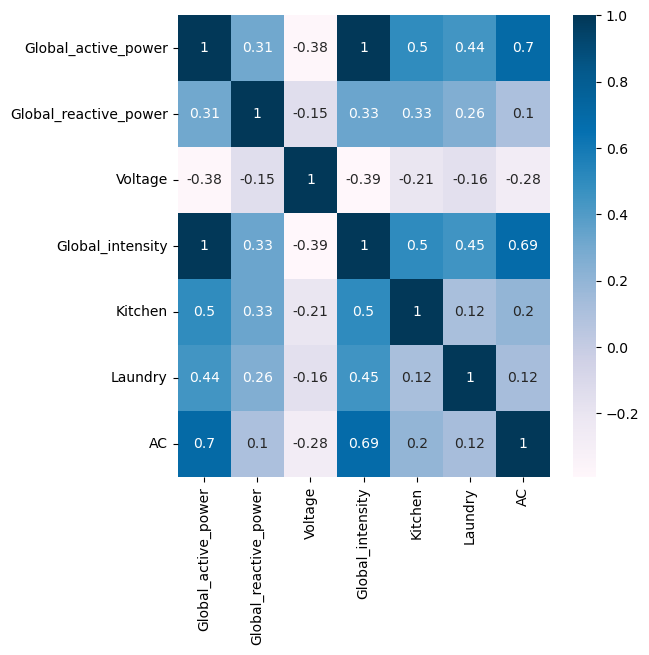

In [82]:
import seaborn as sns
numeric_df = df.select_dtypes(include='number')
fig = plt.figure(figsize=(6,6))
cor = numeric_df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.PuBu)
plt.show()

In [83]:
print(df.isnull().sum())

Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Kitchen                  421
Laundry                  421
AC                       421
dtype: int64


In [84]:
def fillNA(df):
    df.ffill(inplace=True)
    return df

df = fillNA(df)
print(df.isnull().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Kitchen                  0
Laundry                  0
AC                       0
dtype: int64


In [85]:
target = 'Global_active_power'

for lag in [1,2,3,4,6,12,24]:
    df[f'lag_{lag}'] = df[target].shift(lag)

df.dropna(inplace=True) 

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Kitchen,Laundry,AC,lag_1,lag_2,lag_3,lag_4,lag_6,lag_12,lag_24
datetime,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,3.326033,2.985400,2.092633,1.660767,2.471000,1.996733,4.222889
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,3.406767,3.326033,2.985400,2.092633,1.915867,1.303300,3.632200
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,3.697100,3.406767,3.326033,2.985400,1.660767,1.620033,3.400233
2006-12-17 20:00:00,3.361500,0.271500,236.426500,14.276667,0.0,1.116667,17.116667,2.908400,3.697100,3.406767,3.326033,2.092633,1.890567,3.268567
2006-12-17 21:00:00,3.040767,0.267967,239.104167,12.716667,0.0,1.200000,17.500000,3.361500,2.908400,3.697100,3.406767,2.985400,2.549067,3.056467


In [86]:
target = 'Global_active_power'

df["hour"]       = df.index.hour
df["dayofweek"]  = df.index.dayofweek
df["month"]      = df.index.month
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

x = df.drop(columns=[target])
y = df[target]

split_date = "2009-01-01"
x_train = x[x.index < split_date]
x_test  = x[x.index >= split_date]
y_train = y[y.index < split_date]
y_test  = y[y.index >= split_date]

print(f"Train: {len(x_train)} rows")
print(f"Test:  {len(x_test)} rows")

Train: 17887 rows
Test:  16678 rows


In [87]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

model = XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)

param_dist = {
    "n_estimators": randint(100, 300),
    "max_depth": randint(2, 6),
    "learning_rate": uniform(0.05, 0.15),
    "subsample": uniform(0.7, 0.3),
}

search = RandomizedSearchCV(model, param_dist, n_iter=20, cv=2,
                             scoring='r2', random_state=42, n_jobs=-1)
search.fit(x_train, y_train)

print(f"Best CV R²: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Best CV R²: 0.9981
Best params: {'learning_rate': 0.05871254182522992, 'max_depth': 5, 'n_estimators': 216, 'subsample': 0.8803345035229626}


In [88]:
prod = search.best_estimator_
prod

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05871254182522992, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=216, n_jobs=-1,
             num_parallel_tree=None, ...)

In [89]:
prod.score(x_test,y_test)

0.9991984864312446

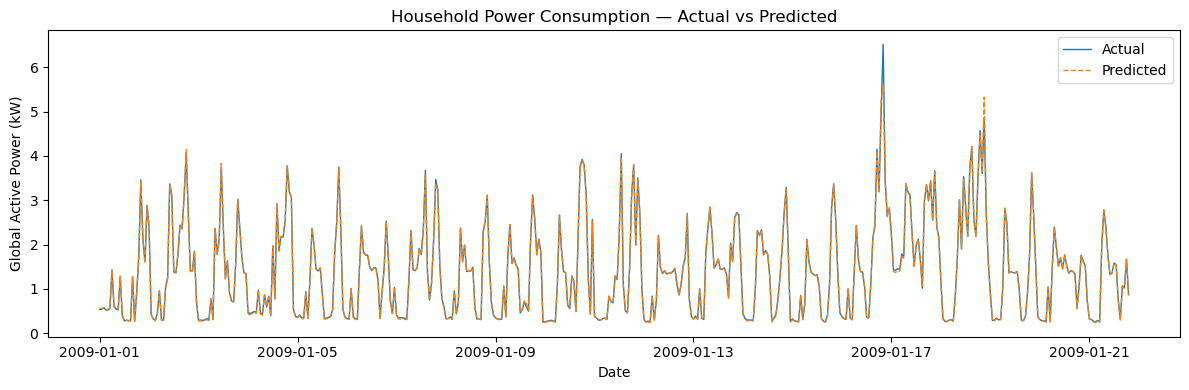

In [91]:
y_pred = prod.predict(x_test)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(y_test.index[:500], y_test.values[:500], label="Actual", linewidth=1)
ax.plot(y_test.index[:500], y_pred[:500], label="Predicted", linewidth=1, linestyle="--")
ax.set_title("Household Power Consumption — Actual vs Predicted")
ax.set_xlabel("Date")
ax.set_ylabel("Global Active Power (kW)")
ax.legend()
plt.tight_layout()
plt.show()

In [92]:
from sklearn.metrics import mean_absolute_error
import numpy as np
print(f"Test R²:   {prod.score(x_test, y_test):.4f}")
print(f"Test RMSE: {np.sqrt(((y_test - y_pred) ** 2).mean()):.4f} kW")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred):.4f} kW")
print(f"Best params: {search.best_params_}")

Test R²:   0.9992
Test RMSE: 0.0231 kW
Test MAE:  0.0129 kW
Best params: {'learning_rate': 0.05871254182522992, 'max_depth': 5, 'n_estimators': 216, 'subsample': 0.8803345035229626}
